# Classifying User Gender Based on Tweet Text
By: ED KING, [Post Link](https://www.kaggle.com/code/kinguistics/classifying-user-gender-based-on-tweet-text/notebook?select=gender-classifier-DFE-791531.csv)

## Download Dataset from Kaggle

In [91]:
# source: https://www.kaggle.com/discussions/general/74235
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d crowdflower/twitter-user-gender-classification

! unzip "twitter-user-gender-classification.zip"

Dataset URL: https://www.kaggle.com/datasets/crowdflower/twitter-user-gender-classification
License(s): CC0-1.0
twitter-user-gender-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  twitter-user-gender-classification.zip
replace gender-classifier-DFE-791531.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: gender-classifier-DFE-791531.csv  


In [92]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt # we'll want this for plotting
import re # we'll want this for text manipulation

from collections import defaultdict # for quick counting

# the Naive Bayes model
from sklearn.naive_bayes import MultinomialNB                # Classifier
from sklearn.model_selection import train_test_split

# function for transforming documents into counts
from sklearn.feature_extraction.text import CountVectorizer  # Vectorizer
from sklearn.feature_extraction.text import TfidfTransformer # Transformer
from sklearn.feature_extraction.text import TfidfVectorizer # Transformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import LabelEncoder # function for encoding categories

from sklearn import metrics

# TASK: investigate why latin1 must be used?
# have to use latin1 even though it results in a lot of dead characters
twigen = pd.read_csv("gender-classifier-DFE-791531.csv", encoding='latin1')

print(twigen['gender'].value_counts()) # How many labels are there for gender
print(len(twigen))
twigen.head()

gender
female     6700
male       6194
brand      5942
unknown    1117
Name: count, dtype: int64
20050


,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,profileimage,retweet_count,sidebar_color,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0000,yes,1.0,12/5/13 1:48,...,https://pbs.twimg.com/profile_images/414342229...,0,FFFFFF,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0000,yes,1.0,10/1/12 13:51,...,https://pbs.twimg.com/profile_images/539604221...,0,C0DEED,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada)
2,815719228,False,finalized,3,10/26/15 23:33,male,0.6625,yes,1.0,11/28/14 11:30,...,https://pbs.twimg.com/profile_images/657330418...,1,C0DEED,i absolutely adore when louis starts the songs...,NaN,5617,10/26/15 12:40,6.587300e+17,clcncl,Belgrade
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0000,yes,1.0,6/11/09 22:39,...,https://pbs.twimg.com/profile_images/259703936...,0,C0DEED,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada)
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0000,yes,1.0,4/16/14 13:23,...,https://pbs.twimg.com/profile_images/564094871...,0,0,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN


# Preprocessing

In [93]:
def normalize_text(s):
    # just in case
    s = str(s)
    s = s.lower()

    # remove punctuation that is not word-internal (e.g., hyphens, apostrophes)
    s = re.sub('\\s\\W',' ',s)
    s = re.sub('\\W\\s',' ',s)

    # make sure we didn't introduce any double spaces
    s = re.sub('\\s+',' ',s)

    return s

twigen['text_norm'] = [normalize_text(s) for s in twigen['text']]
twigen['description_norm'] = [normalize_text(s) for s in twigen['description']]

In [94]:
twigen.head()

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,sidebar_color,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone,text_norm,description_norm
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0000,yes,1.0,12/5/13 1:48,...,FFFFFF,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai,robbie e responds to critics after win against...,i sing my own rhythm.
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0000,yes,1.0,10/1/12 13:51,...,C0DEED,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada),ûïit felt like they were my friends and i was...,i'm the author of novels filled with family dr...
2,815719228,False,finalized,3,10/26/15 23:33,male,0.6625,yes,1.0,11/28/14 11:30,...,C0DEED,i absolutely adore when louis starts the songs...,NaN,5617,10/26/15 12:40,6.587300e+17,clcncl,Belgrade,i absolutely adore when louis starts the songs...,louis whining and squealing and all
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0000,yes,1.0,6/11/09 22:39,...,C0DEED,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada),hi jordanspieth looking at the url do you use ...,mobile guy 49ers shazam google kleiner perkins...
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0000,yes,1.0,4/16/14 13:23,...,0,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN,watching neighbours on sky catching up with th...,ricky wilson the best frontman/kaiser chiefs t...


# Data Cleaning

In [95]:

# how many observations are gold standard?
# golden values(True,False) mean that the entry is 100% reliable and verified
# Source: https://www.geeksforgeeks.org/python/defaultdict-in-python/

# golden_values = labeled by domain experts
# confidence = how many people agree that an entry is reliable
gold_values = defaultdict(int)
for val in twigen._golden:
    gold_values[val] += 1
print(gold_values)

print(np.any(np.isnan(twigen['gender:confidence']))) # what does the confidence look like?

gender_confidence = twigen['gender:confidence'][
    np.where(np.invert(np.isnan(twigen['gender:confidence'])))[0]] # we've got at least one NaN, so let's remove

print(len(gender_confidence))

defaultdict(<class 'int'>, {False: 20000, True: 50})
True
20024


About 30% of the observations have less than 100% confidence in the gender classification, so we'll ignore those.

In [96]:
twigen_confident = twigen[twigen['gender:confidence']==1] # twigen is a pd object, the syntax gets only entries with 1 confidence
print(twigen_confident.shape)

# shows that there are not NaN confidence values
print(np.any(np.isnan(twigen_confident['gender:confidence']))) # There should be no NaN params due the action above.

# Now, we need to get rid of the rows that contain the gender type "unknown" and "brand"
# by explicitly selecting gender values that are in "male" or "female"
twigen_confident = twigen_confident[twigen_confident['gender'].isin(['male','female'])]
print(twigen_confident.shape)

print(twigen_confident['gender'].value_counts())

twigen_confident.head()

(13926, 28)
False
(10020, 28)
gender
female    5367
male      4653
Name: count, dtype: int64


,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,sidebar_color,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone,text_norm,description_norm
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0,yes,1.0,12/5/13 1:48,...,FFFFFF,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai,robbie e responds to critics after win against...,i sing my own rhythm.
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0,yes,1.0,10/1/12 13:51,...,C0DEED,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada),ûïit felt like they were my friends and i was...,i'm the author of novels filled with family dr...
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0,yes,1.0,6/11/09 22:39,...,C0DEED,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada),hi jordanspieth looking at the url do you use ...,mobile guy 49ers shazam google kleiner perkins...
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0,yes,1.0,4/16/14 13:23,...,0,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN,watching neighbours on sky catching up with th...,ricky wilson the best frontman/kaiser chiefs t...
5,815719231,False,finalized,3,10/27/15 1:47,female,1.0,yes,1.0,3/11/10 18:14,...,0,"Ive seen people on the train with lamps, chair...",NaN,20036,10/26/15 12:40,6.587300e+17,New York Gritty,Central Time (US & Canada),ive seen people on the train with lamps chairs...,you don't know me.


# Feauture Engineering

In [97]:
twigen_confident['all_features'] = twigen_confident['text_norm'].str.cat(twigen_confident['description_norm'], sep=' ')
twigen_confident.head()
#twigen_confident = twigen[twigen['gender:confidence']==1]

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,gender,gender:confidence,profile_yn,profile_yn:confidence,created,...,text,tweet_coord,tweet_count,tweet_created,tweet_id,tweet_location,user_timezone,text_norm,description_norm,all_features
0,815719226,False,finalized,3,10/26/15 23:24,male,1.0,yes,1.0,12/5/13 1:48,...,Robbie E Responds To Critics After Win Against...,NaN,110964,10/26/15 12:40,6.587300e+17,main; @Kan1shk3,Chennai,robbie e responds to critics after win against...,i sing my own rhythm.,robbie e responds to critics after win against...
1,815719227,False,finalized,3,10/26/15 23:30,male,1.0,yes,1.0,10/1/12 13:51,...,ÛÏIt felt like they were my friends and I was...,NaN,7471,10/26/15 12:40,6.587300e+17,NaN,Eastern Time (US & Canada),ûïit felt like they were my friends and i was...,i'm the author of novels filled with family dr...,ûïit felt like they were my friends and i was...
3,815719229,False,finalized,3,10/26/15 23:10,male,1.0,yes,1.0,6/11/09 22:39,...,Hi @JordanSpieth - Looking at the url - do you...,NaN,1693,10/26/15 12:40,6.587300e+17,"Palo Alto, CA",Pacific Time (US & Canada),hi jordanspieth looking at the url do you use ...,mobile guy 49ers shazam google kleiner perkins...,hi jordanspieth looking at the url do you use ...
4,815719230,False,finalized,3,10/27/15 1:15,female,1.0,yes,1.0,4/16/14 13:23,...,Watching Neighbours on Sky+ catching up with t...,NaN,31462,10/26/15 12:40,6.587300e+17,NaN,NaN,watching neighbours on sky catching up with th...,ricky wilson the best frontman/kaiser chiefs t...,watching neighbours on sky catching up with th...
5,815719231,False,finalized,3,10/27/15 1:47,female,1.0,yes,1.0,3/11/10 18:14,...,"Ive seen people on the train with lamps, chair...",NaN,20036,10/26/15 12:40,6.587300e+17,New York Gritty,Central Time (US & Canada),ive seen people on the train with lamps chairs...,you don't know me.,ive seen people on the train with lamps chairs...


# Pipeline and Tunning

In [98]:
#vectorizer = TfidfVectorizer(ngram_range=(1,1))
#x = vectorizer.fit_transform(twigen_confident['text_norm'])

encoder = LabelEncoder()
y = encoder.fit_transform(twigen_confident['gender'])

# split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(twigen_confident['all_features'], y, test_size=0.2)
text_clf = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('clf', MultinomialNB()),
    ])

text_clf.fit(twigen_confident['all_features'], y)

Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', MultinomialNB())])

In [99]:
predicted = text_clf.predict(x_test)
np.mean(predicted == y_test)

np.float64(0.8672654690618763)

In [100]:
print(
    f"Classification report for Kaggle dataset:\n"
    f"{metrics.classification_report(y_test, predicted, target_names=encoder.classes_)}\n"
)

Classification report for Kaggle dataset:
              precision    recall  f1-score   support

      female       0.81      0.99      0.89      1086
        male       0.98      0.73      0.83       918

    accuracy                           0.87      2004
   macro avg       0.89      0.86      0.86      2004
weighted avg       0.89      0.87      0.86      2004




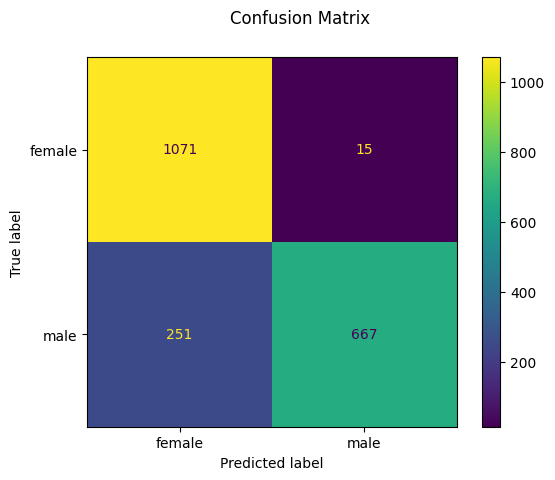

In [101]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(
    y_test, predicted, display_labels=encoder.classes_)
disp.figure_.suptitle("Confusion Matrix")

plt.show()